# تمرین پنجم

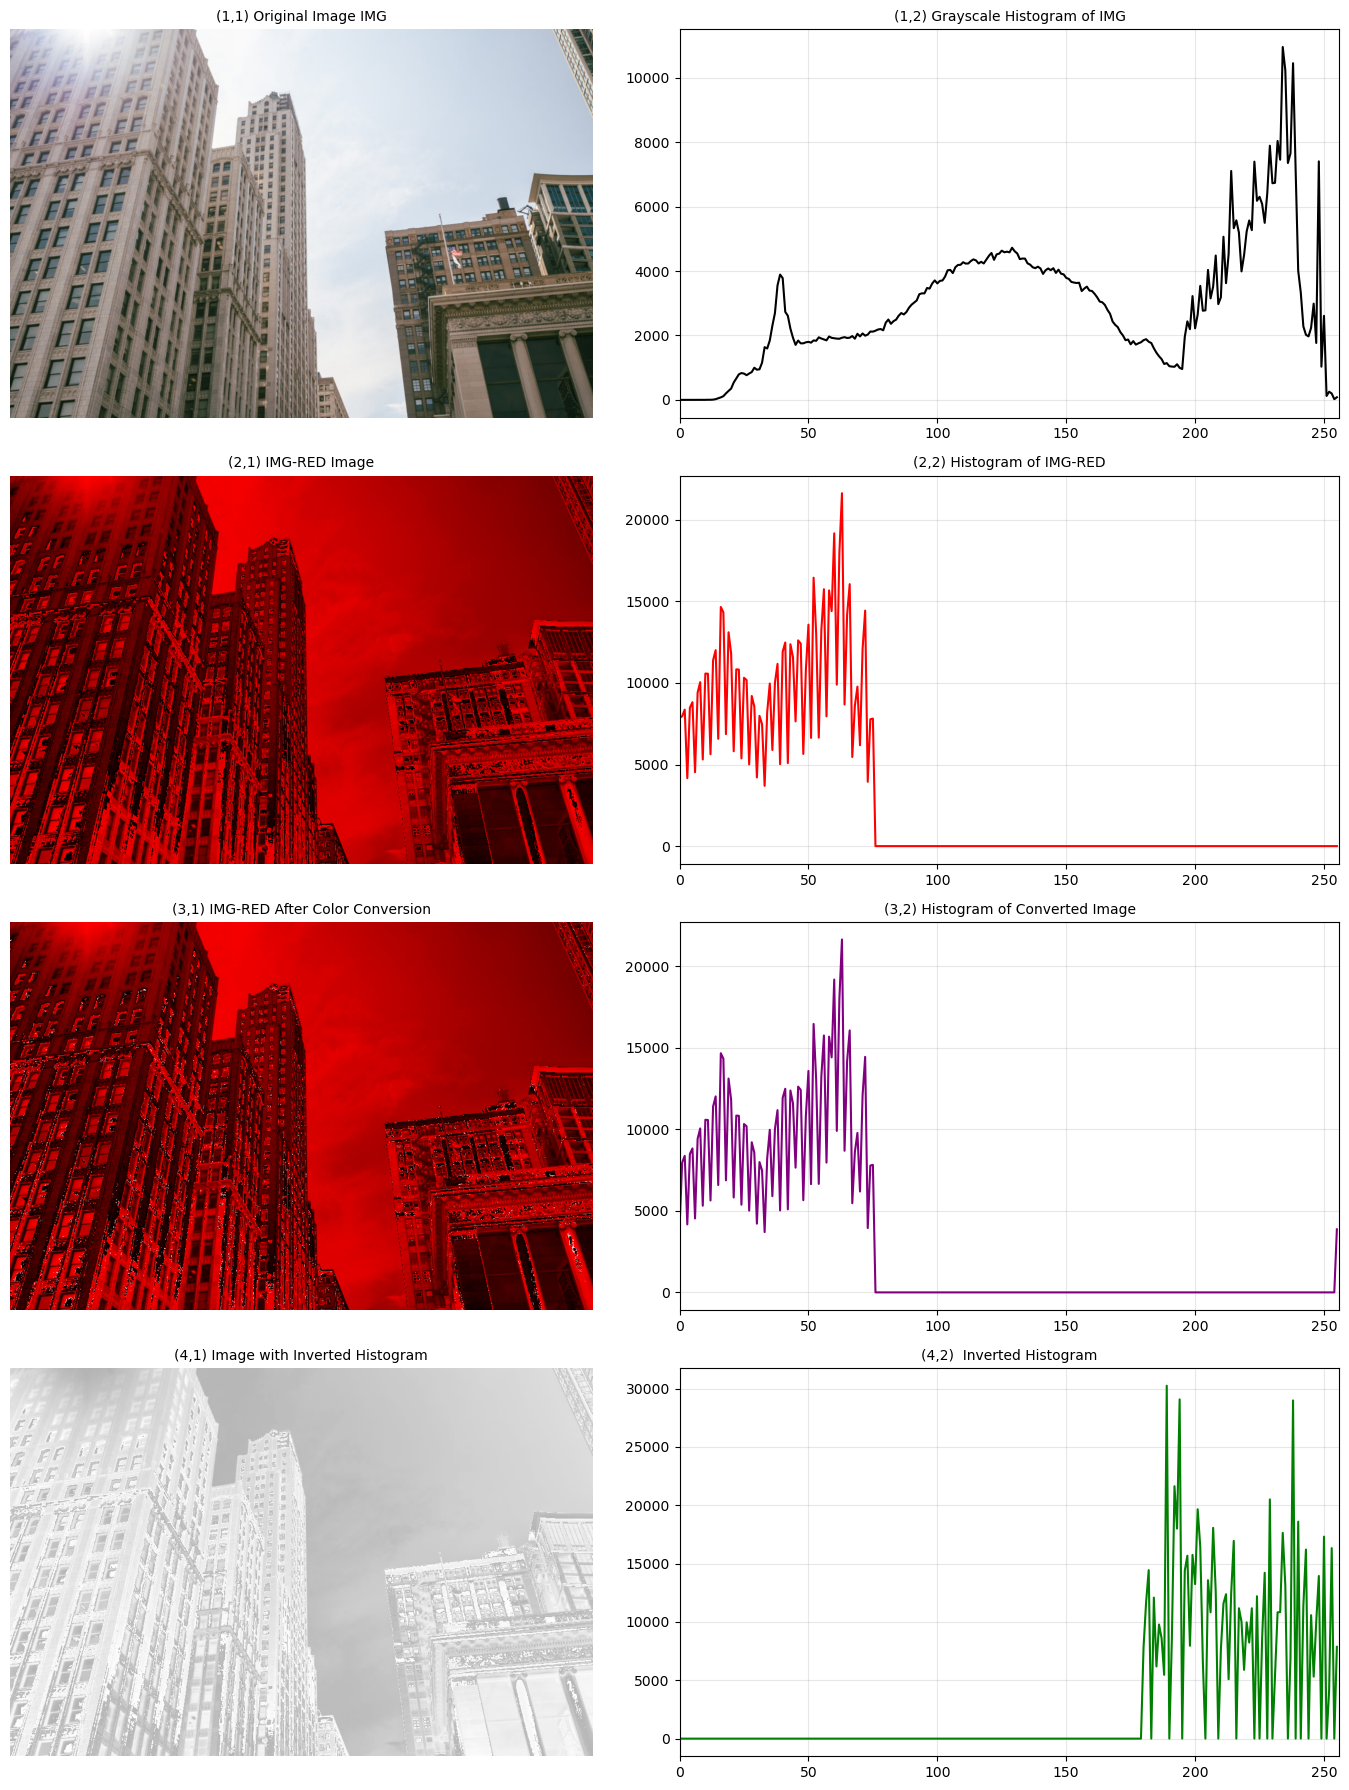

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# کلاس اصلی برنامه
class ImageHistogramProcessor:
    def __init__(self, image_path):
        #  خواندن تصویر رنگی  
        self.img_bgr = cv2.imread(image_path)
        if self.img_bgr is None:
            print("error")
            
        self.img_rgb = cv2.cvtColor(self.img_bgr, cv2.COLOR_BGR2RGB)
        
        # ایجاد کپی از تصویر قرمز شده برای مراحل بعد
        self.img_red = None
        self.img_red_processed = None
        
    def compute_grayscale_histogram(self, image):
         
        # تبدیل به خاکستری با فرمول استاندارد: 0.299*R + 0.587*G + 0.114*B
        gray = np.dot(image[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)
        
        # محاسبه هیستوگرام
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        return hist, gray
    
    def create_red_channel_image(self):
        
        # جدا کردن کانال‌ها
        r, g, b = cv2.split(self.img_rgb)
        
        # دو برابر کردن کانال قرمز و محدود کردن به 255
        r_doubled = r * 2
        r_doubled = np.where(r_doubled > 255, 255, r_doubled)
        r_doubled = r_doubled.astype(np.uint8)
        
        # ساخت تصویر جدید: کانال قرمز تغییر کرده، سبز و آبی صفر
        self.img_red = cv2.merge([r_doubled, np.zeros_like(g), np.zeros_like(b)])
        return self.img_red
    
    def convert_black_white_pixels(self, image):
      
        img_copy = image.copy()
        
        # تشخیص پیکسل‌های سیاه و سفید
        black_pixels = (img_copy[:, :, 0] == 0) & (img_copy[:, :, 1] == 0) & (img_copy[:, :, 2] == 0)
        white_pixels = (img_copy[:, :, 0] == 255) & (img_copy[:, :, 1] == 255) & (img_copy[:, :, 2] == 255)
        
        # تبدیل سیاه به سفید
        img_copy[black_pixels] = [255, 255, 255]
        # تبدیل سفید به سیاه
        img_copy[white_pixels] = [0, 0, 0]
        
        return img_copy
    
    def invert_histogram(self, hist):
       
        inverted_hist = np.zeros_like(hist)
        for i in range(256):
            inverted_hist[i] = hist[255 - i]
        return inverted_hist
    
    def apply_histogram_mapping(self, gray_img, inverted_hist):
      
        # معکوس کردن مستقیم تصویر (255 - gray)
        # این کار باعث معکوس شدن هیستوگرام می‌شود
        mapped_img = 255 - gray_img
        return mapped_img
    
    def run(self):
        
        # بررسی بارگذاری صحیح تصویر
        if self.img_rgb is None:
            return
        
        # ایجاد figure با سایز مناسب
        plt.figure(figsize=(14, 18))
        
        # ===== مرحله 1: تصویر اصلی و هیستوگرام آن =====
        hist_original, gray_original = self.compute_grayscale_histogram(self.img_rgb)
        
        plt.subplot(4, 2, 1)  # موقعیت (1,1)
        plt.imshow(self.img_rgb)
        plt.title("(1,1) Original Image IMG", fontsize=10)
        plt.axis('off')
        
        plt.subplot(4, 2, 2)  # موقعیت (1,2)
        plt.plot(hist_original, color='black')
        plt.title("(1,2) Grayscale Histogram of IMG", fontsize=10)
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.3)
        
        
        self.create_red_channel_image()
        hist_red, gray_red = self.compute_grayscale_histogram(self.img_red)
        
        plt.subplot(4, 2, 3)  # موقعیت (2,1)
        plt.imshow(self.img_red)
        plt.title("(2,1) IMG-RED Image", fontsize=10)
        plt.axis('off')
        
        plt.subplot(4, 2, 4)  # موقعیت (2,2)
        plt.plot(hist_red, color='red')
        plt.title("(2,2) Histogram of IMG-RED", fontsize=10)
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.3)
        
       
        self.img_red_processed = self.convert_black_white_pixels(self.img_red)
        hist_processed, gray_processed = self.compute_grayscale_histogram(self.img_red_processed)
        
        plt.subplot(4, 2, 5)  # موقعیت (3,1)
        plt.imshow(self.img_red_processed)
        plt.title("(3,1) IMG-RED After Color Conversion", fontsize=10)
        plt.axis('off')
        
        plt.subplot(4, 2, 6)  # موقعیت (3,2)
        plt.plot(hist_processed, color='purple')
        plt.title("(3,2) Histogram of Converted Image", fontsize=10)
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.3)
        
        # محاسبه هیستوگرام معکوس
        inverted_hist = self.invert_histogram(hist_red)
        
        # اعمال معکوس هیستوگرام روی تصویر
        _, gray_red_for_invert = self.compute_grayscale_histogram(self.img_red)
        
        # اعمال نگاشت جدید
        img_inverted = self.apply_histogram_mapping(gray_red_for_invert, inverted_hist)
        
        # تبدیل به RGB برای نمایش (چون تک کاناله شده)
        img_inverted_rgb = cv2.cvtColor(img_inverted, cv2.COLOR_GRAY2RGB)
        
        # هیستوگرام معکوس نهایی
        hist_inverted_final, _ = self.compute_grayscale_histogram(img_inverted_rgb)
        
        plt.subplot(4, 2, 7)  # موقعیت (4,1)
        plt.imshow(img_inverted_rgb)
        plt.title("(4,1) Image with Inverted Histogram", fontsize=10)
        plt.axis('off')
        
        plt.subplot(4, 2, 8)  # موقعیت (4,2)
        plt.plot(hist_inverted_final, color='green')
        plt.title("(4,2)  Inverted Histogram", fontsize=10)
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        plt.show()



image_name = "./4.JPG"

processor = ImageHistogramProcessor(image_name)

processor.run()